# GTFS Data Exploration

**Purpose**: Explore Warsaw transit stop data. Explore Ochota district bus stops.

**Input**: data/raw/gtfs/stops.txt  

**Output**: data/processed/warsaw_stops.csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import folium
import numpy as np

In [2]:
PROJECT_DIR = Path.cwd().parent.parent
RAW_DATA = PROJECT_DIR / "data" / "raw" / "stops.txt"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"

In [3]:
stops = pd.read_csv(RAW_DATA)

In [4]:
stops.head()

,stop_id,stop_name,stop_code,platform_code,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding,zone_id,stop_name_stem,town_name,street_name
0,100101,Kijowska,01,NaN,52.248455,21.044827,0,NaN,1,1,Kijowska,Warszawa,Targowa
1,100102,Kijowska,02,NaN,52.249078,21.044443,0,NaN,1,1,Kijowska,Warszawa,Targowa
2,100103,Kijowska,03,NaN,52.248928,21.044169,0,NaN,1,1,Kijowska,Warszawa,Targowa
3,100104,Kijowska,04,NaN,52.249969,21.041588,0,NaN,1,1,Kijowska,Warszawa,Targowa
4,100106,Kijowska,06,NaN,52.250078,21.043848,0,NaN,1,1,Kijowska,Warszawa,Kijowska


In [5]:
f"There are {len(stops)} total stops."

'There are 7185 total stops.'

In [6]:
stops.describe()

,stop_lat,stop_lon,location_type,wheelchair_boarding
count,7185.000000,7185.000000,7185.000000,7185.00000
mean,52.227585,21.019290,0.075713,1.10842
std,0.097646,0.116561,0.374733,0.31138
min,51.921869,20.586367,0.000000,0.00000
25%,52.177033,20.949265,0.000000,1.00000
50%,52.233125,21.016529,0.000000,1.00000
75%,52.284161,21.083361,0.000000,1.00000
max,52.493519,21.463783,2.000000,2.00000


In [7]:
for column in stops.columns:
    print(
        f"Column {column} is of type {type(column)} and has {stops[column].isnull().sum()} None values"
    )

Column stop_id is of type <class 'str'> and has 0 None values
Column stop_name is of type <class 'str'> and has 0 None values
Column stop_code is of type <class 'str'> and has 315 None values
Column platform_code is of type <class 'str'> and has 7183 None values
Column stop_lat is of type <class 'str'> and has 0 None values
Column stop_lon is of type <class 'str'> and has 0 None values
Column location_type is of type <class 'str'> and has 0 None values
Column parent_station is of type <class 'str'> and has 6893 None values
Column wheelchair_boarding is of type <class 'str'> and has 0 None values
Column zone_id is of type <class 'str'> and has 0 None values
Column stop_name_stem is of type <class 'str'> and has 330 None values
Column town_name is of type <class 'str'> and has 330 None values
Column street_name is of type <class 'str'> and has 397 None values


In [8]:
stops["stop_lat"] = stops["stop_lat"].astype(float)
stops["stop_lon"] = stops["stop_lon"].astype(float)

Let's focus on the Ochota disctrict bus stops. 

In [9]:
from src.config import OCHOTA_BOUNDS

In [10]:
ochota_stops = stops[
    (stops["stop_lat"] > OCHOTA_BOUNDS["min_lat"])
    & (stops["stop_lat"] < OCHOTA_BOUNDS["max_lat"])
    & (stops["stop_lon"] > OCHOTA_BOUNDS["min_lon"])
    & (stops["stop_lon"] < OCHOTA_BOUNDS["max_lon"])
].copy()

In [11]:
ochota_stops.head()

,stop_id,stop_name,stop_code,platform_code,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding,zone_id,stop_name_stem,town_name,street_name
3743,328601,Rakowiecka - Sanktuarium,01,NaN,52.205211,20.999071,0,NaN,1,1,Rakowiecka - Sanktuarium,Warszawa,Św. A. Boboli
3744,328602,Rakowiecka - Sanktuarium,02,NaN,52.206381,20.999281,0,NaN,1,1,Rakowiecka - Sanktuarium,Warszawa,Św. A. Boboli
3745,328603,Rakowiecka - Sanktuarium,03,NaN,52.205155,20.999400,0,NaN,1,1,Rakowiecka - Sanktuarium,Warszawa,Św. A. Boboli
3746,328604,Rakowiecka - Sanktuarium,04,NaN,52.205617,20.999336,0,NaN,1,1,Rakowiecka - Sanktuarium,Warszawa,Św. A. Boboli
4547,400102,Pl. Zawiszy,02,NaN,52.224696,20.987462,0,NaN,1,1,Pl. Zawiszy,Warszawa,Al. Jerozolimskie


In [12]:
ochota_stops["stop_name"].unique().tolist()

['Rakowiecka - Sanktuarium',
 'Pl. Zawiszy',
 'Ochota - Ratusz',
 'Pl. Narutowicza',
 'Och-Teatr',
 'Bitwy Warszawskiej 1920 r.',
 'Dickensa',
 'Korotyńskiego',
 'CH Blue City',
 'Raszyńska',
 'Pomnik Lotnika',
 'Banacha - Szpital',
 'Uniwersytet Medyczny',
 'Pruszkowska',
 'Spiska',
 'Białobrzeska',
 'Grzymały-Sokołowskiego',
 'Dw. Zachodni',
 'Rondo Zesłańców Syberyjskich',
 'Śmigłowca',
 'PKP WKD Al. Jerozolimskie',
 'Berestecka',
 'Pl. Starynkiewicza',
 'Na Bateryjce',
 'Al. Bohaterów Września',
 'Instalatorów',
 'Skorochód-Majewskiego',
 'Banacha',
 'Siemieńskiego',
 'Mołdawska',
 'Wiślicka',
 'Hala Kopińska',
 'Opaczewska',
 'Szczęśliwice',
 'Urbanistów',
 'Wawelska',
 'Al. Wielkopolski',
 'CH Reduta',
 'Hale Banacha',
 'Niemcewicza',
 'Lindleya',
 'NIK',
 'Szczęśliwicka',
 'Harfowa',
 'Przy Parku',
 'Maszynowa',
 'Dobosza',
 'Wschodu Słońca',
 'Szybka',
 'Przemyska',
 'Warszawa Zachodnia',
 'Warszawa Ochota',
 'Warszawa Aleje Jerozolimskie',
 'Elekcyjna',
 'Reduta Wolska',
 'Ron

In [13]:
f"There are {len(ochota_stops)} bus stops in Ochota District."

'There are 219 bus stops in Ochota District.'

Let's look at the real map with these coordinates.

In [14]:
bounds_loc = [
    [OCHOTA_BOUNDS["min_lat"], OCHOTA_BOUNDS["min_lon"]],  # Southwest corner (lat, lon)
    [OCHOTA_BOUNDS["max_lat"], OCHOTA_BOUNDS["max_lon"]],  # Northeast corner (lat, lon)
]
center_loc = [
    np.mean([OCHOTA_BOUNDS["min_lat"], OCHOTA_BOUNDS["max_lat"]]),
    np.mean([OCHOTA_BOUNDS["min_lon"], OCHOTA_BOUNDS["max_lon"]]),
]

In [15]:
m = folium.Map(location=center_loc, zoom_start=13)

In [16]:
folium.Rectangle(
    bounds=bounds_loc, color="green", fill=True, fill_color="green", fill_opacity=0.3
).add_to(m)

In [17]:
m.save(PROJECT_DIR / "artifacts" / "figures" / "notebook01" / "ochota_map.html")

One can check the considered Ochota District map by clicking [here](../../artifacts/figures/ochota_map.html).

Let's find out the distribution of stop codes in the Ochota district

In [18]:
stop_codes = ochota_stops["stop_code"].tolist()
stop_codes_series = pd.Series(stop_codes).value_counts().sort_index()

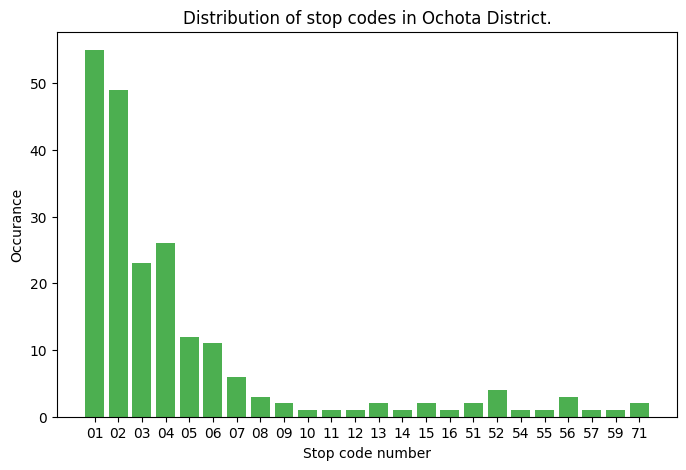

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(stop_codes_series.index, stop_codes_series.values, color="#4CAF50")
plt.xlabel("Stop code number")
plt.ylabel("Occurance")
plt.title("Distribution of stop codes in Ochota District.")
plt.savefig(
    PROJECT_DIR
    / "artifacts"
    / "figures"
    / "notebook01"
    / "stop_codes_distributions.png"
)
plt.show()
plt.close()

Lastly, let's save it.

In [20]:
ochota_stops.to_csv(PROCESSED_DATA_DIR / "ochota_stops.csv", index=False)
print(f"Saved {len(ochota_stops)} stops")

Saved 219 stops
